Saving svm_farming_datasets.xlsx to svm_farming_datasets (5).xlsx
DataSet Loaded Successfully !

  Sample ID  Soil Nitrogen (mg/kg)  Avg Rainfall (mm)  Class Label    Class
0      W001                  70.83             602.05            1  Healthy
1      W002                  75.15             556.55            1  Healthy
2      W003                  92.58             698.62            1  Healthy
3      W004                  84.47             608.76            1  Healthy
4      W005                  66.91             723.59            1  Healthy

=== RESULT FOR C=0.01===
Accuracy: 1.0
Confusion Matrix:
 [[ 9  0]
 [ 0 12]]
Classification Report:
               precision    recall  f1-score   support

          -1       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21


=== RESULT FOR C=

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


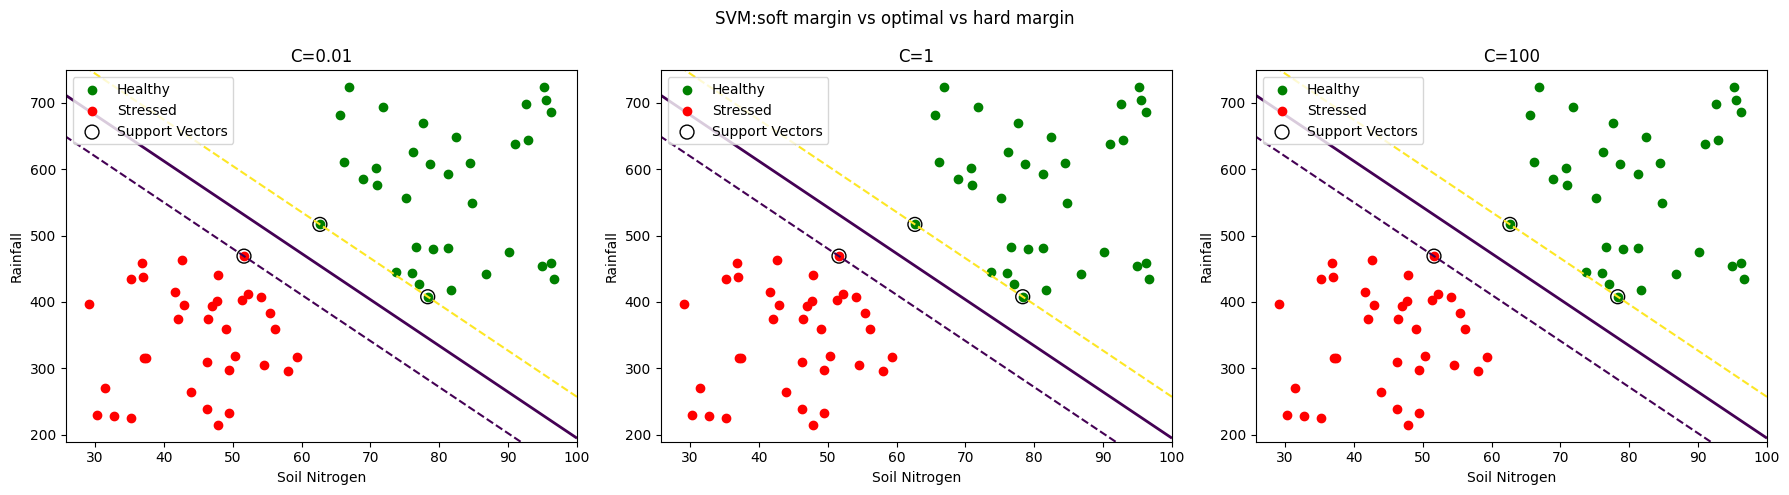

In [6]:
#==== SVM Complete pipeline ( local Upload- colab)====

# Upload file from local system
from google.colab import files
uploaded=files.upload()

# get uploaded file name automatically
file_name= list(uploaded.keys())[0]

#2. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# 3. Load dataset
# FIX : Changed pd.read_csv to pd.read_excel for.xlsx files
df = pd.read_excel(file_name)

print("DataSet Loaded Successfully !\n")
print (df.head())

# 4. Clean column names(important)
df.columns=df.columns.str.strip()

# Rename soil Nitrogen and Rainfall columns
df.rename(columns={
    "Soil Nitrogen (mg/kg)":"Soil_Nitrogen",
    "Avg Rainfall (mm)":"Rainfall"
},inplace=True)

# Drop the 'Sample ID'column as it's not a feature or target

if"Sample ID" in df.columns:
  df.drop(columns=["Sample ID"],inplace=True)

# Ensure the 'Class' column contains numerical labels for the model.

if'Class Label' in df.columns and 'Class' in df.columns:
  df.drop(columns=['Class'],inplace=True)


if 'Class Label' in df.columns:
  df.rename(columns={"Class Label":"Class"},inplace=True)

#5. Features and Labels

x=df[["Soil_Nitrogen","Rainfall"]]
y=df["Class"]

# 6.Train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

#7.Function:Train +Evaluate +Plot

def train_and_plot(C,subplot_index):
  model=svm.SVC(kernel='linear',C=C)
  model.fit(x_train,y_train)

  # Predictions
  y_pred= model.predict(x_test)

  # Evaluation
  print(f"\n=== RESULT FOR C={C}===")
  print("Accuracy:", accuracy_score(y_test,y_pred))
  print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
  print("Classification Report:\n", classification_report(y_test,y_pred))

  # Plotting
  plt.subplot(1,3,subplot_index)

  for label,color in zip([1,-1],['green','red']):
    subset=df[df["Class"]==label]
    plt.scatter(subset["Soil_Nitrogen"],
                subset["Rainfall"],
                c=color,
                label=("Healthy" if label == 1 else "Stressed"))

  # Decision boundary
  ax=plt.gca()
  xlim=ax.get_xlim()
  ylim=ax.get_ylim()

  xx=np.linspace(xlim[0],xlim[1],30)
  yy=np.linspace(ylim[0],ylim[1],30)
  yy,xx=np.meshgrid(yy,xx)

  xy=np.vstack([xx.ravel(),yy.ravel()]).T
  z=model.decision_function(xy).reshape(xx.shape)

  # Boundary
  ax.contour(xx,yy,z,levels=[0],linewidths=2)

  # Margins
  ax.contour(xx,yy,z,levels=[-1,1],linestyles=['--','--'])

  # Support vectors
  ax.scatter(model.support_vectors_[:,0],
             model.support_vectors_[:,1],
             s=100,facecolors='none',
             edgecolors='black',
             label='Support Vectors')
  plt.xlabel("Soil Nitrogen")
  plt.ylabel("Rainfall")
  plt.title(f"C={C}")
  plt.legend()

# 8. Compare different C values

plt.figure(figsize=(18,5))
C_values=[0.01,1,100]

for i, C in enumerate(C_values):
  train_and_plot(C, i+1)

plt.suptitle("SVM:soft margin vs optimal vs hard margin")
plt.tight_layout()
plt.show()